# DBSCAN Clustering

DBSCAN stands for:

**Density-Based Spatial Clustering of Applications with Noise**

DBSCAN is an unsupervised clustering algorithm that groups observations based on the density of data points.

Unlike K-Means, DBSCAN does not require us to specify the number of clusters beforehand.

DBSCAN can also identify observations that do not belong to any cluster. These observations are called **noise** or **outliers**.

### Main Advantages

- Does not require the number of clusters beforehand
- Can discover irregularly shaped clusters
- Can identify noise and outliers
- Works well when clusters are separated by regions of low density

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.shape

(344, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [5]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].dropna()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [9]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(
    X_scaled
)

labels[:20]

array([ 0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0, -1,  0,  0, -1,
        0, -1, -1])

In [10]:
result = X.copy()

result["Cluster"] = labels

result.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,0


In [11]:
result["Cluster"].value_counts().sort_index()

Cluster
-1     69
 0    118
 1     15
 2     27
 3    113
Name: count, dtype: int64

In [12]:
n_clusters = len(
    set(labels)
) - (1 if -1 in labels else 0)

print(
    "Number of clusters:",
    n_clusters
)

Number of clusters: 4


In [13]:
noise_count = np.sum(
    labels == -1
)

print(
    "Number of noise points:",
    noise_count
)

Number of noise points: 69


In [14]:
noise_percentage = (
    noise_count / len(labels)
) * 100

print(
    f"Noise Percentage: {noise_percentage:.2f}%"
)

Noise Percentage: 20.18%


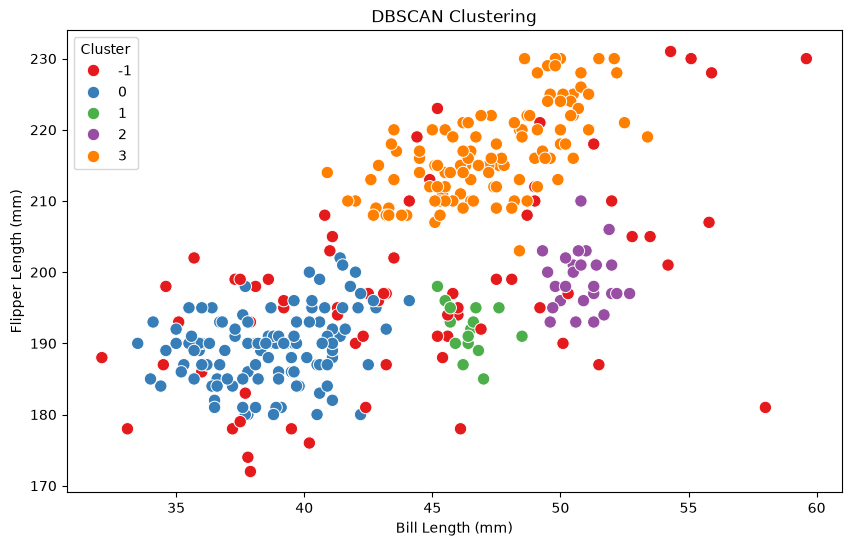

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=result,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title(
    "DBSCAN Clustering"
)

plt.xlabel(
    "Bill Length (mm)"
)

plt.ylabel(
    "Flipper Length (mm)"
)

plt.show()

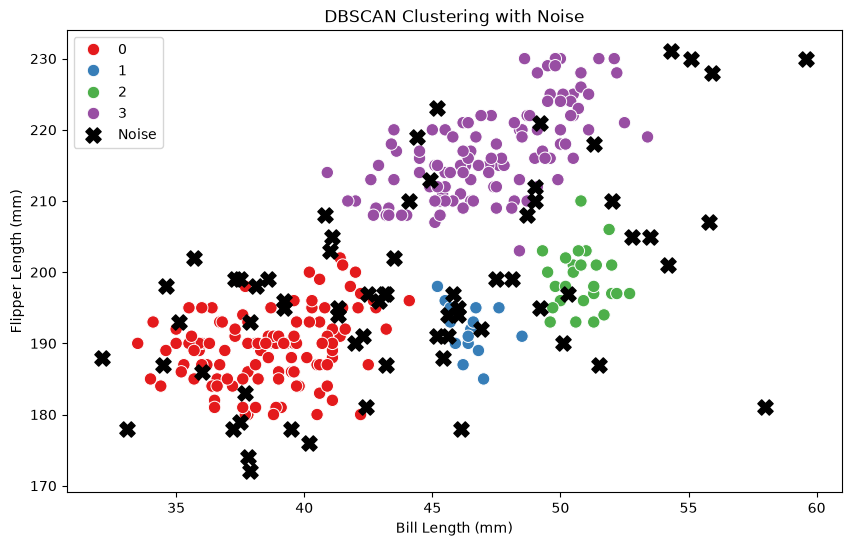

In [16]:
plt.figure(figsize=(10, 6))

# Normal clusters
clustered = result[
    result["Cluster"] != -1
]

sns.scatterplot(
    data=clustered,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

# Noise
noise = result[
    result["Cluster"] == -1
]

plt.scatter(
    noise["bill_length_mm"],
    noise["flipper_length_mm"],
    marker="X",
    s=120,
    color="black",
    label="Noise"
)

plt.title(
    "DBSCAN Clustering with Noise"
)

plt.xlabel(
    "Bill Length (mm)"
)

plt.ylabel(
    "Flipper Length (mm)"
)

plt.legend()

plt.show()